In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# Exploratory Data Analysis

In [4]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [5]:
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [6]:
sample_submission.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [7]:
train.shape

(198000, 15)

In [8]:
X = train.drop(columns=['label'])
y = train['label']

In [9]:
X.shape

(198000, 14)

In [10]:
y.shape

(198000,)

In [11]:
X.isna().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
dtype: int64

In [12]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0


In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 19.8+ MB


Let us now check whether the target is balanced

In [14]:
y.value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [15]:
y.value_counts(normalize=True)

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='Count'>

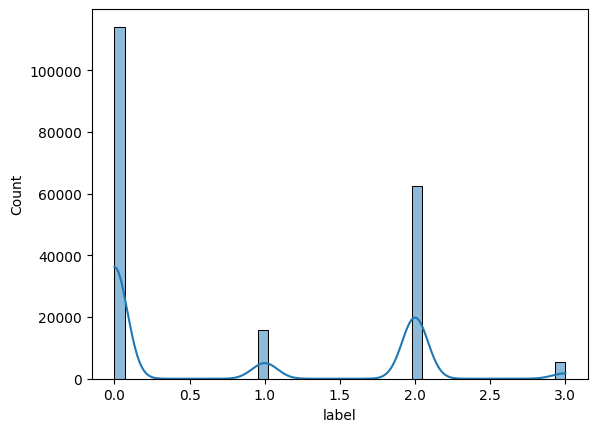

In [16]:
sns.histplot(y, kde=True)

This shows us that the dataset is clearly imabalnced. Class 0 dominates with 114173(57%) samples, class 2 with 62440(31%) samples, class 1 with 15918(8%) samples and class 3 with 5469(2%) samples. This means accuracy alone will be a misleading metric; a model that always predicts class 0 would still score high. We'll use **macro F1-score** to evaluate models fairly across all classes.

Let us now print the **categorical** and **numerical** features seperately:

In [17]:
cat = X.select_dtypes(include=['object', 'bool']).columns.to_list()
num = X.select_dtypes(include=['int64']).columns.to_list()
print(f"Categorical features: {cat}")
print(f"Numerical features: {num}")

Categorical features: ['created_date', 'race', 'religion', 'gender', 'disability', 'comment']
Numerical features: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']


In [18]:
X['created_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 198000 entries, 0 to 197999
Series name: created_date
Non-Null Count   Dtype 
--------------   ----- 
198000 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [19]:
X['created_date'] = pd.to_datetime(X['created_date'])

In [20]:
X['created_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 198000 entries, 0 to 197999
Series name: created_date
Non-Null Count   Dtype              
--------------   -----              
198000 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1)
memory usage: 1.5 MB


Let us now drop the duplicate entries from the feature matrix:

In [21]:
print(f"Shape of training data before removing the duplicates: {X.shape}")
X.drop_duplicates(inplace=True)
print(f"Shape of training data after removing the duplicates: {X.shape}")

Shape of training data before removing the duplicates: (198000, 14)
Shape of training data after removing the duplicates: (198000, 14)


It is clear that the shape of training data before and after removing the duplicate entries is the same. Hence, there are no duplicate entries in the training data. 

Plotting histograms for all the numerical features:

In [22]:
numerical_columns = num

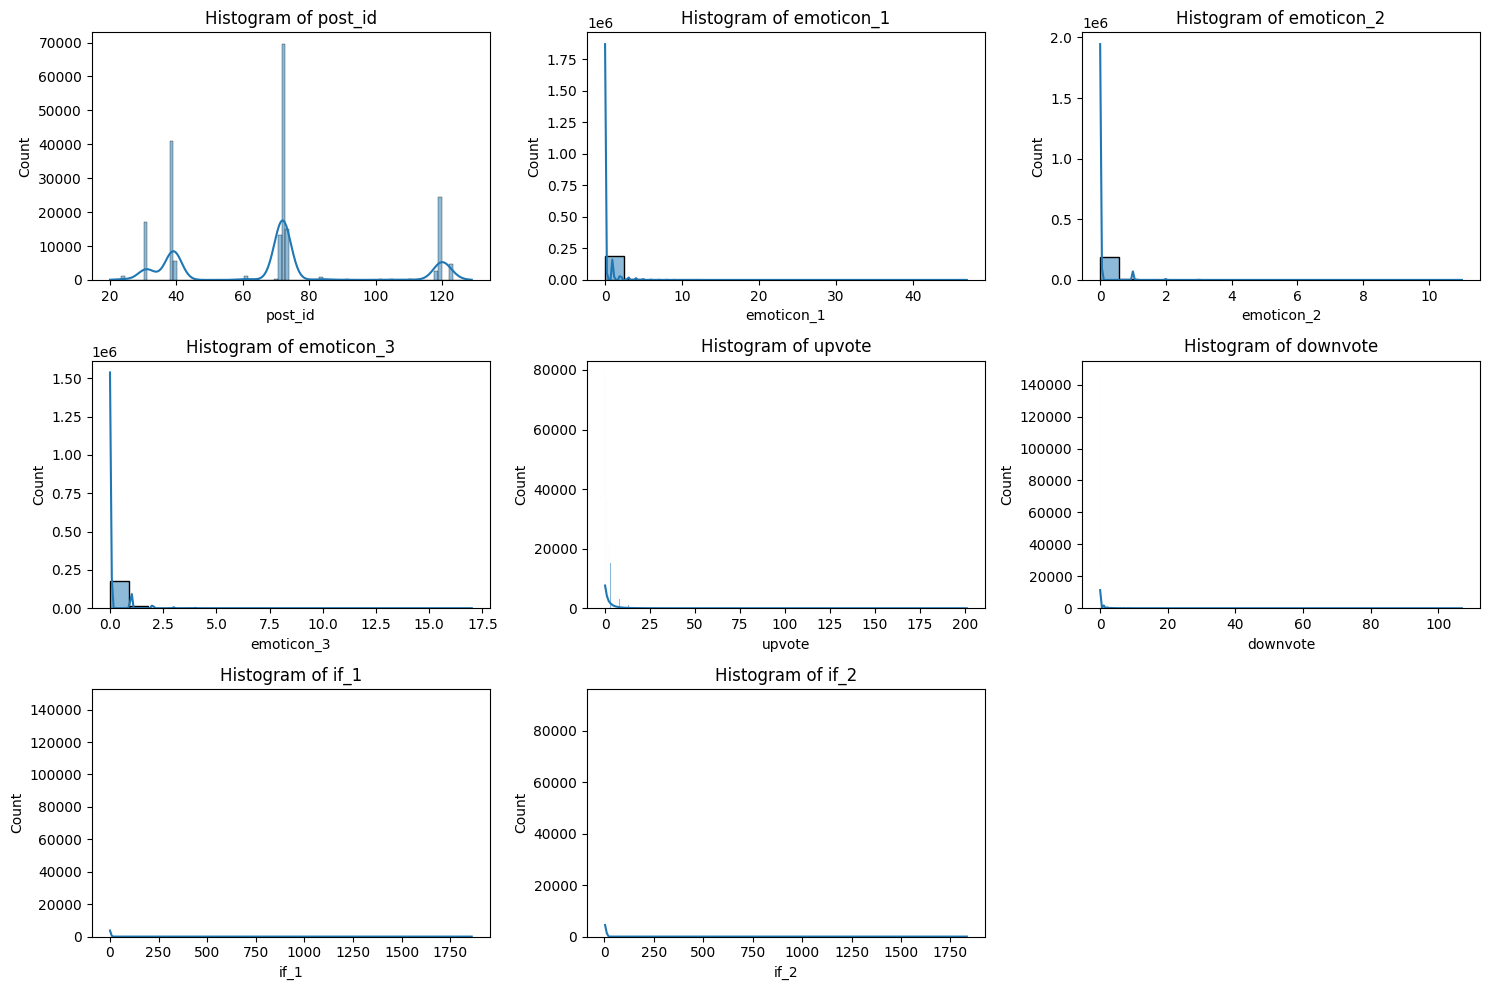

In [23]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(train[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

**`post_id`** shows a few distinct spikes, indicating that comments are concentrated around a small set of posts rather than spread evenly. This is expected for a news/discussion platform where popular articles attract most of the engagement.

**`emoticon_1`, `emoticon_2`, `emoticon_3`** are all heavily right-skewed with the vast majority of values at zero. Most comments simply don't have emoticons, so these features will be sparse but may still be useful for identifying expressive or emotional comments.

**`upvote` & `downvote`** follow a similar zero-heavy pattern with a long right tail. A small number of comments receive very high engagement, which could indicate highly controversial or widely agreed-upon content, both potentially linked to comment category.

**`if_1` & `if_2`** also show extreme skewness with values stretching into the thousands. These represent some kind of interaction score, and the outliers may carry meaningful signal.

Plotting Box plot fo all numerical features:

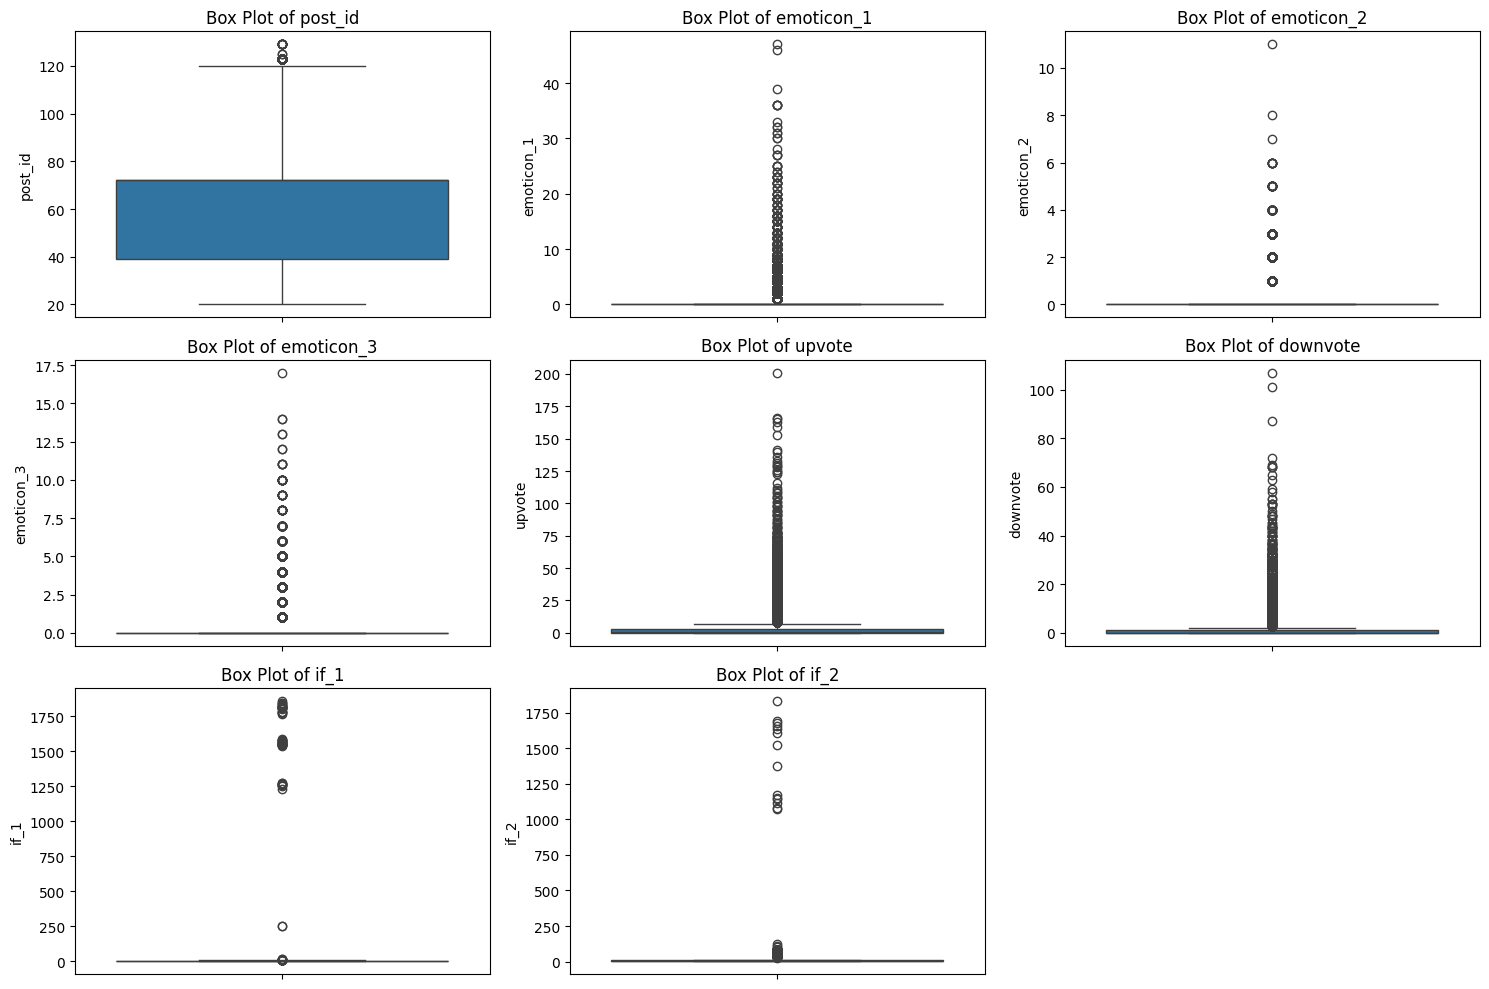

In [24]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=train[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

Almost every feature except `post_id` has its Inter-Quartile Range(IQR) compressed near zero with a large number of outliers. 

`upvote`, `downvote`, `if_1` and `if_2` are the most extreme, with outliers going well beyond 100 in some cases. `post_id` is the only feature with a reasonably spread box, which makes sense since it's just an identifier rather than an engagement metric.

Also, these outliers cannot be removed blindly, since a comment with a very high value of `if_2` is likely meaningfully different from a average comment. So removing them would lose useful signal.

Visualizing the distributions of categorical variables

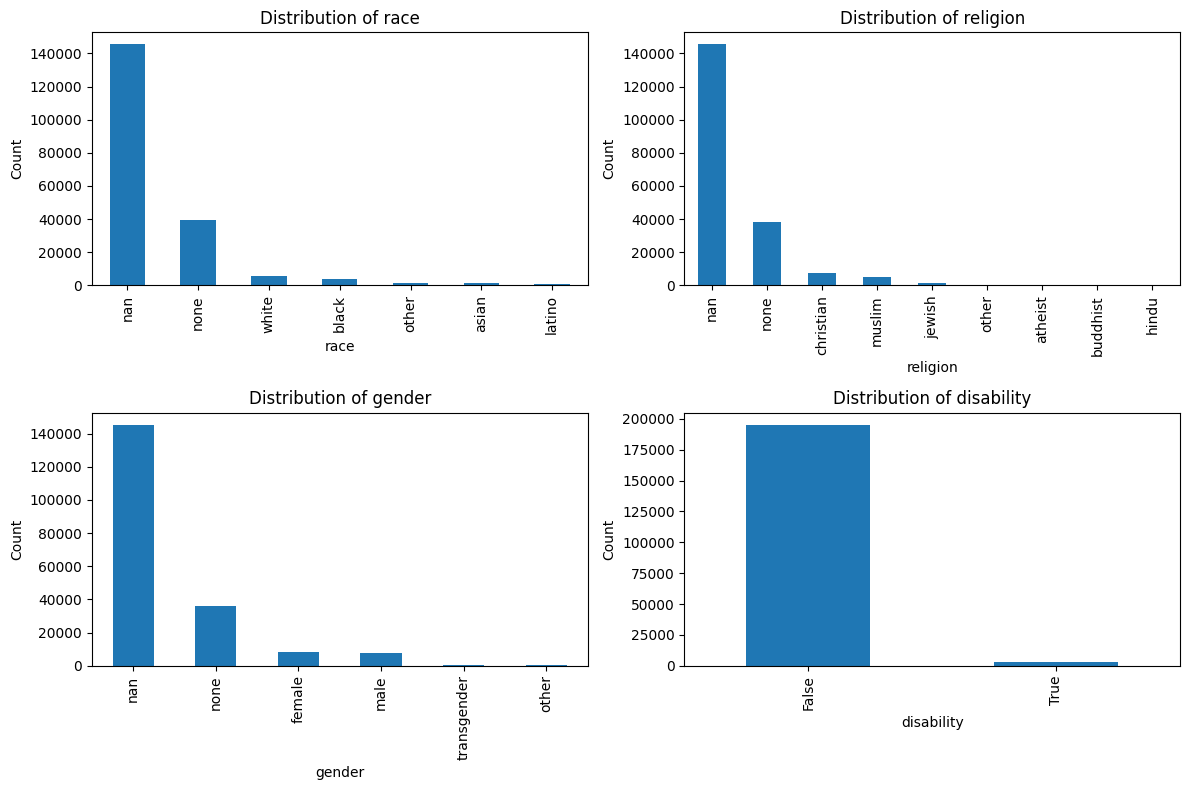

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(['race', 'religion', 'gender', 'disability']):
    ax = axes[i//2, i%2]
    train[col].value_counts(dropna=False).plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Count')
    
plt.tight_layout()
plt.show()

From the plots of `race`, `religion` and `gender`, we can clearly observe that most of the entries are 'NaN' values. Where values do exist, 'none' is the most common, meaning that the comments weren't directed at any specific group. Also, the `disability` column is almost entirely false. 

These colums are too sparse to be strong predictors on their own, but they retained wth imputation rather than being dropped entirely. 

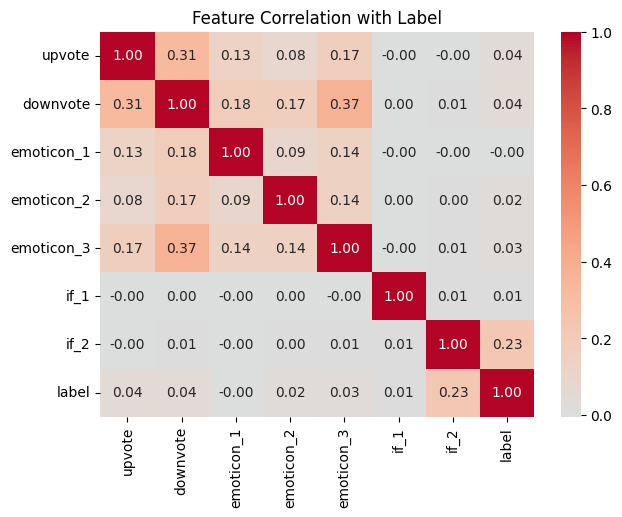

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
            'if_1', 'if_2'] + ['label']

plt.figure(figsize=(7, 5))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation with Label")
plt.show()


From the correlation heatmap, we can clearly observe that most of the features are weakly correlated with the `label`. the highest correlation observed is `if_2` with a value of 0.23. This means that the numerical features alone won't be enough to build a strong classifier and the real signal lies in the text feature `comment`.

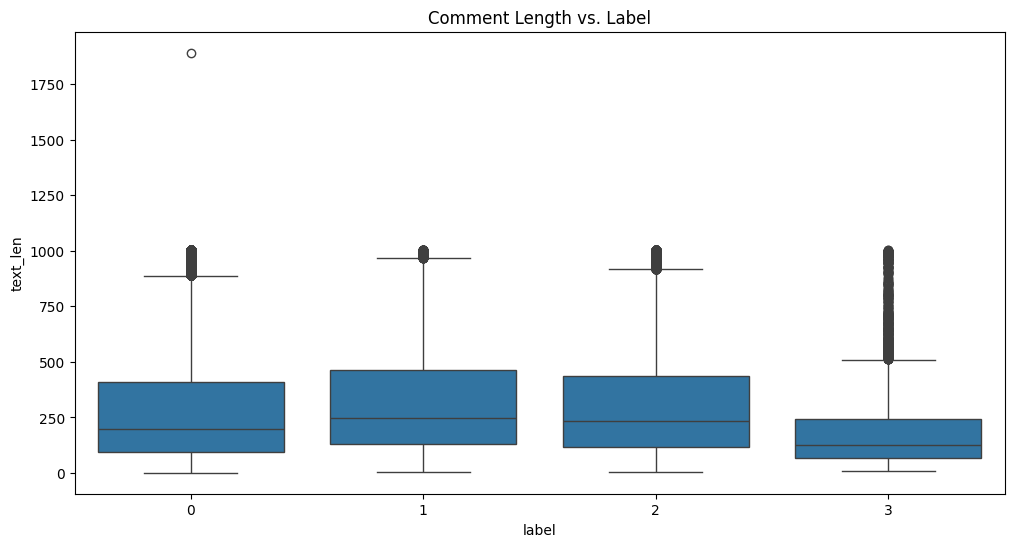

Average Length by Class:
label
0    295.897279
1    335.709700
2    316.893418
3    194.171695
Name: text_len, dtype: float64


In [27]:
# Text Length Analysis
train['text_len'] = train['comment'].astype(str).apply(len)

plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='label', y='text_len')
plt.title("Comment Length vs. Label")

plt.show()

print("Average Length by Class:")
print(train.groupby('label')['text_len'].mean())


Class 1 has the highest average comment length (335 characters) while class 3 is the shortest with 194 characters. this suggests that commments that belong to class 3 is more direct/blunt language whereas comments that belong to class 1 could represent elaborate discussion. 

# Preprocessing and Feature Engineering/Extraction

In [28]:
train_df = train.copy()
test_df  = test.copy()
y_full = train_df['label']

print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Train: (198000, 16), Test: (102000, 14)


Since, the number of outliers is higher we are capping(Winsorizing) the values above 99th percentile rather than removing the rown that would result in loss of data. 

In [29]:
# Outlier handling
outlier_features = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']
for col in outlier_features:
    if col in train_df.columns:
        q99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(upper=q99)
        test_df[col]  = test_df[col].clip(upper=q99)

print("Outliers are capped to 99th percentile.")

Outliers are capped to 99th percentile.


In [30]:
# Datetime features
def extract_datetime_features(df):
    dt = pd.to_datetime(df['created_date'], utc=True)
    df = df.copy()
    df['hour'] = dt.dt.hour
    df['dayofweek'] = dt.dt.dayofweek
    df['month'] = dt.dt.month
    df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    return df

train_df = extract_datetime_features(train_df)
test_df  = extract_datetime_features(test_df)
print("Datetime features extracted.")

Datetime features extracted.


In [31]:
# Text features
def extract_text_features(df):
    df = df.copy()
    comment = df['comment'].fillna('')
    
    df['comment_len'] = comment.str.len()
    df['word_count'] = comment.str.split().str.len()
    df['upper_count'] = comment.str.count(r'[A-Z]')
    df['upper_ratio'] = df['upper_count'] / (df['comment_len'] + 1)
    df['exclamation_count'] = comment.str.count(r'!')
    df['question_count'] = comment.str.count(r'\?')
    df['punct_count'] = comment.str.count(r'[^\w\s]')
    df['digit_count'] = comment.str.count(r'\d')
    df['avg_word_length'] = df['comment_len'] / (df['word_count'] + 1)
    df['is_very_short'] = (df['comment_len'] < 200).astype(int)
    df['length_category'] = pd.cut(df['comment_len'], 
                                    bins=[0, 200, 300, 400, 10000], 
                                    labels=[0, 1, 2, 3])
    df['length_category'] = df['length_category'].cat.codes.fillna(0).astype(int)
    return df

train_df = extract_text_features(train_df)
test_df  = extract_text_features(test_df)
print("Text features have been extracted.")

Text features have been extracted.


In [32]:
# Categorical encoding
for col in ['race', 'religion', 'gender']:
    train_df[col] = train_df[col].fillna('missing')
    test_df[col]  = test_df[col].fillna('missing')

for col in ['race', 'religion', 'gender']:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

post_freq = train_df['post_id'].value_counts().to_dict()
train_df['post_id_freq'] = train_df['post_id'].map(post_freq).fillna(0)
test_df['post_id_freq']  = test_df['post_id'].map(post_freq).fillna(0)

train_df['disability'] = train_df['disability'].astype(int)
test_df['disability']  = test_df['disability'].astype(int)

print("Categorical encoding complete.")

Categorical encoding complete.


In [33]:
# Interaction features
train_df['net_vote'] = train_df['upvote'] - train_df['downvote']
test_df['net_vote']  = test_df['upvote'] - test_df['downvote']

train_df['vote_ratio'] = train_df['upvote'] / (train_df['downvote'] + 1)
test_df['vote_ratio']  = test_df['upvote'] / (test_df['downvote'] + 1)

print("Interaction features created.")

Interaction features created.


In [34]:
NUMERICAL_FEATURES = [
    'post_id_freq', 'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'net_vote', 'vote_ratio',
    'if_1', 'if_2', 'hour', 'dayofweek', 'month', 'is_weekend',
    'comment_len', 'word_count', 'upper_count', 'upper_ratio',
    'exclamation_count', 'question_count', 'punct_count', 'digit_count',
    'avg_word_length', 'is_very_short', 'length_category',
    'race', 'religion', 'gender', 'disability'
]

TEXT_FEATURE = 'comment'

### Creating Features for SGD(100k features) 

SGD with elasticnet works well with high dimensional data because the l1 regularization automatically selects the important features and zeros out the rest. 

In [35]:
train_df[TEXT_FEATURE] = train_df[TEXT_FEATURE].fillna('')
test_df[TEXT_FEATURE]  = test_df[TEXT_FEATURE].fillna('')

# Word level
tfidf_word_sgd = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode'
)

# Char level
tfidf_char_sgd = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=55000,
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode'
)

# Trigrams 
tfidf_trigram_sgd = TfidfVectorizer(
    analyzer='word',
    ngram_range=(3, 3),
    max_features=15000,
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode'
)

print("Fitting SGD TF-IDF vectorizers...")
X_word_sgd_train = tfidf_word_sgd.fit_transform(train_df[TEXT_FEATURE])
X_word_sgd_test  = tfidf_word_sgd.transform(test_df[TEXT_FEATURE])

X_char_sgd_train = tfidf_char_sgd.fit_transform(train_df[TEXT_FEATURE])
X_char_sgd_test  = tfidf_char_sgd.transform(test_df[TEXT_FEATURE])

X_trigram_sgd_train = tfidf_trigram_sgd.fit_transform(train_df[TEXT_FEATURE])
X_trigram_sgd_test  = tfidf_trigram_sgd.transform(test_df[TEXT_FEATURE])

X_tfidf_sgd_train = hstack([X_word_sgd_train, X_char_sgd_train, X_trigram_sgd_train])
X_tfidf_sgd_test  = hstack([X_word_sgd_test, X_char_sgd_test, X_trigram_sgd_test])

print(f"SGD TF-IDF shape: {X_tfidf_sgd_train.shape}")

Fitting SGD TF-IDF vectorizers...
SGD TF-IDF shape: (198000, 100000)


In [36]:
# Combine with numerical features
scaler_sgd = MaxAbsScaler()
X_num_train = train_df[NUMERICAL_FEATURES].values.astype('float32')
X_num_test  = test_df[NUMERICAL_FEATURES].values.astype('float32')

X_num_sgd_scaled = scaler_sgd.fit_transform(X_num_train)
X_num_sgd_test_scaled = scaler_sgd.transform(X_num_test)

X_num_sgd_sparse = csr_matrix(X_num_sgd_scaled)
X_num_sgd_test_sparse = csr_matrix(X_num_sgd_test_scaled)

X_sgd_train = hstack([X_tfidf_sgd_train, X_num_sgd_sparse])
X_sgd_test  = hstack([X_tfidf_sgd_test, X_num_sgd_test_sparse])

print(f"final shape: {X_sgd_train.shape}")

# Train test split
X_sgd_tr, X_sgd_val, y_tr, y_val = train_test_split(
    X_sgd_train, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"SGD Train: {X_sgd_tr.shape[0]}, Val: {X_sgd_val.shape[0]}")

final shape: (198000, 100029)
SGD Train: 158400, Val: 39600


### Creating features for LightGBM & Logistic Regression(19k features)

In [37]:
# Word level
tfidf_word_compact = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode'
)

# Char level
tfidf_char_compact = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=6000,
    sublinear_tf=True,
    min_df=5,
    strip_accents='unicode'
)

# Trigrams
tfidf_trigram_compact = TfidfVectorizer(
    analyzer='word',
    ngram_range=(3, 3),
    max_features=3000,
    sublinear_tf=True,
    min_df=5,
    strip_accents='unicode'
)

print("Fitting compact TF-IDF vectorizers...")
X_word_compact_train = tfidf_word_compact.fit_transform(train_df[TEXT_FEATURE])
X_word_compact_test  = tfidf_word_compact.transform(test_df[TEXT_FEATURE])

X_char_compact_train = tfidf_char_compact.fit_transform(train_df[TEXT_FEATURE])
X_char_compact_test  = tfidf_char_compact.transform(test_df[TEXT_FEATURE])

X_trigram_compact_train = tfidf_trigram_compact.fit_transform(train_df[TEXT_FEATURE])
X_trigram_compact_test  = tfidf_trigram_compact.transform(test_df[TEXT_FEATURE])

X_tfidf_compact_train = hstack([X_word_compact_train, X_char_compact_train, X_trigram_compact_train])
X_tfidf_compact_test  = hstack([X_word_compact_test, X_char_compact_test, X_trigram_compact_test])

print(f"Compact TF-IDF shape: {X_tfidf_compact_train.shape}")

Fitting compact TF-IDF vectorizers...
Compact TF-IDF shape: (198000, 19000)


In [38]:
# Combine with the numerical features
scaler_compact = MaxAbsScaler()
X_num_compact_scaled = scaler_compact.fit_transform(X_num_train)
X_num_compact_test_scaled = scaler_compact.transform(X_num_test)

X_num_compact_sparse = csr_matrix(X_num_compact_scaled)
X_num_compact_test_sparse = csr_matrix(X_num_compact_test_scaled)

X_compact_train = hstack([X_tfidf_compact_train, X_num_compact_sparse])
X_compact_test  = hstack([X_tfidf_compact_test, X_num_compact_test_sparse])

print(f"final shape: {X_compact_train.shape}")

# Train Test Split
X_compact_tr, X_compact_val, _, _ = train_test_split(
    X_compact_train, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"LGBM/LR Train: {X_compact_tr.shape[0]}, Val: {X_compact_val.shape[0]}")

final shape: (198000, 19029)
LGBM/LR Train: 158400, Val: 39600


# Model Training

Each model uses its optimized feature set.

In [39]:
model_scores = {}

### Model 1: SGD Classifier

In [40]:
print("Model 1: SGD")

sgd_model = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    alpha=1e-5,
    l1_ratio=0.4,
    max_iter=4000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

sgd_model.fit(X_sgd_tr, y_tr)
sgd_preds = sgd_model.predict(X_sgd_val)
sgd_f1 = f1_score(y_val, sgd_preds, average='macro')
model_scores['SGD'] = sgd_f1

print(f"Validation Macro F1: {sgd_f1:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, sgd_preds))

Model 1: SGD
Validation Macro F1: 0.80915

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.71      0.82      0.76      3183
           2       0.87      0.89      0.88     12488
           3       0.56      0.73      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.78      0.84      0.81     39600
weighted avg       0.91      0.91      0.91     39600



### Model 2: LightGBM(Best performing model)

In [41]:
print("Model 2: LightGBM")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.85,
    reg_alpha=0.4,
    reg_lambda=2.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_compact_tr, y_tr, eval_set=[(X_compact_val, y_val)])
lgbm_preds = lgbm_model.predict(X_compact_val)
lgbm_f1 = f1_score(y_val, lgbm_preds, average='macro')
model_scores['LightGBM'] = lgbm_f1

print(f"Validation Macro F1: {lgbm_f1:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, lgbm_preds))

Model 2: LightGBM
Validation Macro F1: 0.82008

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.71      0.86      0.78      3183
           2       0.89      0.88      0.88     12488
           3       0.58      0.75      0.66      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.86      0.82     39600
weighted avg       0.92      0.91      0.91     39600



### Model 3: Logistic Regression

In [42]:
print("Model 3: Logistic Regression")

lr_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear',
    random_state=42,
)

lr_model.fit(X_compact_tr, y_tr)
lr_preds = lr_model.predict(X_compact_val)
lr_f1 = f1_score(y_val, lr_preds, average='macro')
model_scores['Logistic Reg'] = lr_f1

print(f"Validation Macro F1: {lr_f1:.5f}")
print("\nClassification Report:")
print(classification_report(y_val, lr_preds))

Model 3: Logistic Regression
Validation Macro F1: 0.79593

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     22835
           1       0.69      0.81      0.75      3183
           2       0.87      0.88      0.87     12488
           3       0.55      0.70      0.61      1094

    accuracy                           0.90     39600
   macro avg       0.77      0.83      0.80     39600
weighted avg       0.90      0.90      0.90     39600



# Model Comparison

Comparing the base models
 Rank        Model  Validation Macro F1
    1     LightGBM             0.820079
    2          SGD             0.809152
    3 Logistic Reg             0.795926

Best Model: LightGBM | F1 = 0.8201


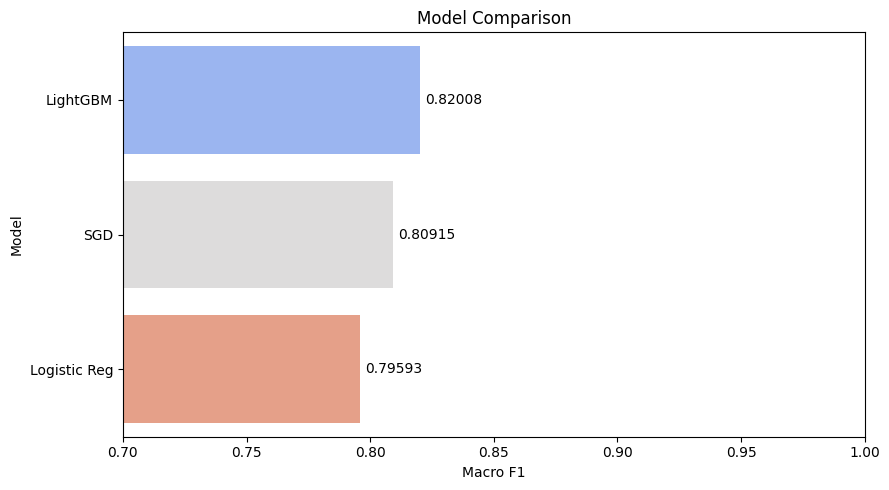

In [43]:
comparison_df = pd.DataFrame(
    list(model_scores.items()),
    columns=['Model', 'Validation Macro F1']
).sort_values('Validation Macro F1', ascending=False).reset_index(drop=True)

comparison_df['Rank'] = comparison_df.index + 1

print("Comparing the base models")
print(comparison_df[['Rank', 'Model', 'Validation Macro F1']].to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_score = comparison_df.iloc[0]['Validation Macro F1']

print(f"\nBest Model: {best_model_name} | F1 = {best_score:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x='Validation Macro F1', y='Model', palette='coolwarm')
plt.title('Model Comparison')
plt.xlabel('Macro F1')
plt.xlim(0.7, 1.0)
for i, row in comparison_df.iterrows():
    plt.text(row['Validation Macro F1'] + 0.002, i,
             f"{row['Validation Macro F1']:.5f}", va='center')
plt.tight_layout()
plt.show()

LightGBM achieved the highest Macro F1 score of 0.820, followed by SGD at 0.809 and Logistic Regression at 0.796. The relatively close scores across all three 
models suggested that ensembling them would smooth out individual weakness,making LightGBM the candidate for hyperparameter tuning.

# Hyperparameter Tuning



In [44]:
print("Hyperparameter Tuning")

print(f"Best model: {best_model_name} (F1: {best_score:.4f})")

if 'SGD' in best_model_name:
    params = {'alpha': [5e-6, 1e-5, 2e-5], 'l1_ratio': [0.35, 0.4, 0.45, 0.5], 'max_iter': [3000, 4000, 5000]}
    model = SGDClassifier(loss='log_loss', penalty='elasticnet', class_weight='balanced', random_state=42, n_jobs=-1)
    X_tr, X_val, X_test = X_sgd_tr, X_sgd_val, X_sgd_test
elif 'LightGBM' in best_model_name:
    params = {'learning_rate': [0.03, 0.04]}
    model = lgb.LGBMClassifier(n_estimators=300, num_leaves=63, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    X_tr, X_val, X_test = X_compact_tr, X_compact_val, X_compact_test
else:
    params = {'C': [0.5, 1.0, 2.0, 5.0]}
    model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
    X_tr, X_val, X_test = X_compact_tr, X_compact_val, X_compact_test

search = RandomizedSearchCV(model, params, n_iter=2, cv=2, scoring='f1_macro', random_state=42, n_jobs=1, verbose=2)
search.fit(X_tr, y_tr)
tuned_model = search.best_estimator_
tuned_f1 = f1_score(y_val, tuned_model.predict(X_val), average='macro')

print(f"Best params: {search.best_params_}")
print(f"Before tuning: {best_score:.5f} | After tuning: {tuned_f1:.5f}")
model_scores[f'{best_model_name} (Tuned)'] = tuned_f1


Hyperparameter Tuning
Best model: LightGBM (F1: 0.8201)
Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END .................................learning_rate=0.03; total time=37.3min
[CV] END .................................learning_rate=0.03; total time=37.6min
[CV] END .................................learning_rate=0.04; total time=37.1min
[CV] END .................................learning_rate=0.04; total time=37.2min
Best params: {'learning_rate': 0.04}
Before tuning: 0.82008 | After tuning: 0.81409


# Ensembling 

In [45]:
print("Creating two ensembles")

# Ensemble 1: With tuned model
if 'SGD' in best_model_name:
    sgd_1, lgbm_1, lr_1 = tuned_model, lgbm_model, lr_model
elif 'LightGBM' in best_model_name:
    sgd_1, lgbm_1, lr_1 = sgd_model, tuned_model, lr_model
else:
    sgd_1, lgbm_1, lr_1 = sgd_model, lgbm_model, tuned_model

ens1_p = (sgd_1.predict_proba(X_sgd_val) + lgbm_1.predict_proba(X_compact_val) + lr_1.predict_proba(X_compact_val)) / 3
ens1_f1 = f1_score(y_val, ens1_p.argmax(axis=1), average='macro')

# Ensemble 2: With all base models 
ens2_p = (sgd_model.predict_proba(X_sgd_val) + lgbm_model.predict_proba(X_compact_val) + lr_model.predict_proba(X_compact_val)) / 3
ens2_f1 = f1_score(y_val, ens2_p.argmax(axis=1), average='macro')

print(f"Ensemble (with tuned {best_model_name}):  {ens1_f1:.4f}")
print(f"Ensemble (all original models): {ens2_f1:.4f}")

# keep whichever scored higher on val
if ens1_f1 >= ens2_f1:
    model_scores['Ensemble (Tuned)'] = ens1_f1
    sgd_f, lgbm_f, lr_f = sgd_1, lgbm_1, lr_1
    print(f"Using ensemble with tuned {best_model_name}")
else:
    model_scores['Ensemble (Original)'] = ens2_f1
    sgd_f, lgbm_f, lr_f = sgd_model, lgbm_model, lr_model
    print("Using ensemble with all original models")


Creating two ensembles
Ensemble (with tuned LightGBM):  0.8299
Ensemble (all original models): 0.8306
Using ensemble with all original models


# Final Comparison & Submission

In [46]:
df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'F1']).sort_values('F1', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))
best = df.iloc[0]['Model']

if 'Ensemble' in best:
    p = (sgd_f.predict_proba(X_sgd_test) + lgbm_f.predict_proba(X_compact_test) + lr_f.predict_proba(X_compact_test)) / 3
    preds = p.argmax(axis=1)
elif 'SGD' in best:
    preds = sgd_f.predict(X_sgd_test)
elif 'LightGBM' in best:
    preds = lgbm_f.predict(X_compact_test)
else:
    preds = lr_f.predict(X_compact_test)

pd.DataFrame({'ID': sample_submission['ID'], 'label': preds}).to_csv('submission.csv', index=False)
print(f"Best model for submission: {best}")

              Model       F1
Ensemble (Original) 0.830629
           LightGBM 0.820079
   LightGBM (Tuned) 0.814091
                SGD 0.809152
       Logistic Reg 0.795926
Best model for submission: Ensemble (Original)
